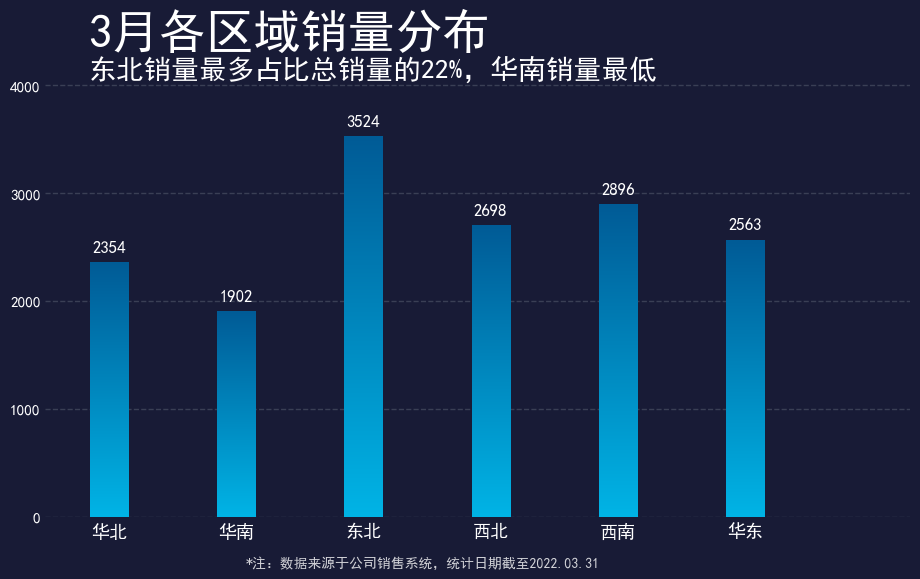

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# 设置中文字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
matplotlib.rcParams['axes.unicode_minus'] = False

# 数据
regions = ['华北', '华南', '东北', '西北', '西南', '华东']
sales = [2354, 1902, 3524, 2698, 2896, 2563]

# 颜色定义
bg_color = '#181B36'        # 深蓝背景
text_color = '#FFFFFF'      # 纯白色文字 (清晰锐利)
grid_color = '#3A3F55'      # 网格线颜色

# 渐变颜色定义 (RGB 0-1) - 顶部深蓝，底部亮蓝
color_top = np.array([0, 91, 150]) / 255.0   # 顶部深蓝
color_bot = np.array([0, 180, 230]) / 255.0  # 底部亮蓝

# 创建画布
fig, ax = plt.subplots(figsize=(10, 6.5))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# 【核心修改】柱宽调细至 0.3，让所有柱子都像华北一样修长
bar_width = 0.3
x_positions = np.arange(len(regions)) + 0.5 

# 绘制渐变柱状图
for i, (x_pos, val) in enumerate(zip(x_positions, sales)):
    rows = 256
    gradient_array = np.zeros((rows, 1, 3))
    for r in range(rows):
        ratio = r / (rows - 1)
        gradient_array[r, 0, :] = color_bot + (color_top - color_bot) * ratio
    
    left = x_pos - bar_width / 2
    right = x_pos + bar_width / 2
    
    # 使用 bilinear 平滑插值，消除锯齿，保证视觉宽度绝对一致
    ax.imshow(gradient_array, aspect='auto', extent=[left, right, 0, val],
              origin='lower', zorder=2, interpolation='bilinear')

# 在柱子上方添加数值标签 (纯白，加粗)
for i, (x_pos, val) in enumerate(zip(x_positions, sales)):
    ax.text(
        x_pos, val + 80,
        str(val),
        ha='center', va='bottom',
        color=text_color,
        fontsize=12,
        fontweight='bold',
        zorder=3
    )

# 设置标题
ax.text(0.05, 1.12, '3月各区域销量分布',
        transform=ax.transAxes,
        fontsize=34, fontweight='bold', color=text_color,
        va='top', ha='left')

ax.text(0.05, 1.02, '东北销量最多占比总销量的22%，华南销量最低',
        transform=ax.transAxes,
        fontsize=20, fontweight='normal', color=text_color,
        va='top', ha='left')

# 设置坐标轴
ax.set_xticks(x_positions)
ax.set_xticklabels(regions, color=text_color, fontsize=13)
ax.tick_params(axis='x', length=0)

# 【核心修改】强制设置X轴范围，给左侧留出空间，防止华北柱子被挤压
ax.set_xlim(0, len(regions) + 0.8) 

ax.set_ylim(0, 4200)
ax.set_yticks([0, 1000, 2000, 3000, 4000])
ax.set_yticklabels(['0', '1000', '2000', '3000', '4000'], color=text_color, fontsize=11)
ax.tick_params(axis='y', length=0)

# 设置网格线
ax.yaxis.grid(True, linestyle='--', color=grid_color, linewidth=1, zorder=1)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# 隐藏边框
for spine in ax.spines.values():
    spine.set_visible(False)

# 添加底部注释
fig.text(
    0.32, 0.06,
    '*注：数据来源于公司销售系统，统计日期截至2022.03.31',
    color=text_color,
    fontsize=10,
    alpha=0.8
)

# 调整布局
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.subplots_adjust(left=0.12)

plt.show()


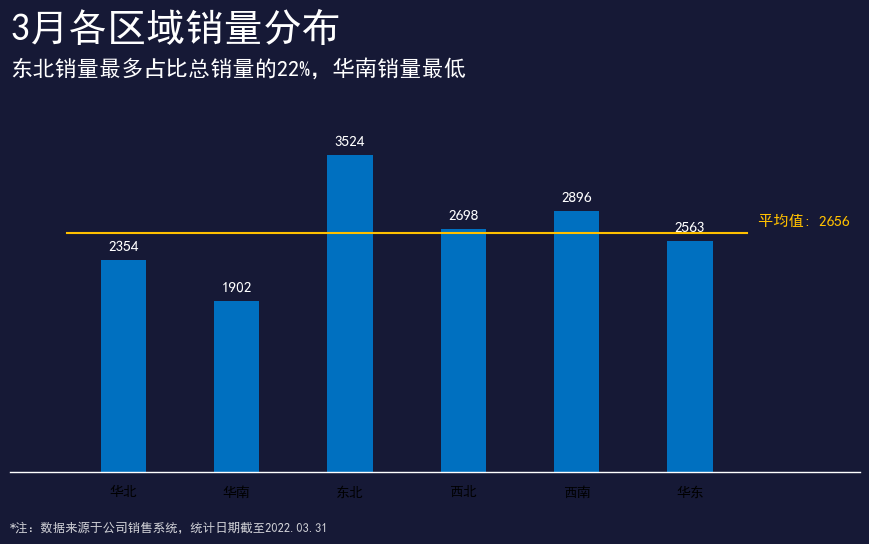

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# 设置中文字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
matplotlib.rcParams['axes.unicode_minus'] = False

# 数据
regions = ['华北', '华南', '东北', '西北', '西南', '华东']
sales = [2354, 1902, 3524, 2698, 2896, 2563]
avg_sales = 2656

# 颜色定义 (完全匹配图1)
bg_color = '#161936'        # 深蓝背景
text_color = '#FFFFFF'      # 纯白色文字
line_color = '#FFC000'      # 平均值线 (橙黄色)
bar_color = '#0070C0'       # 柱子主色 (图1看起来接近纯色，这里用标准蓝)

# 1. 创建画布 (不使用 subplots，手动控制布局以防重叠)
fig = plt.figure(figsize=(10, 6))
fig.patch.set_facecolor(bg_color)

# 2. 放置标题 (在 Figure 坐标系中，y=0.9 附近，绝对在图表上方)
fig.text(0.1, 0.92, '3月各区域销量分布', 
         color=text_color, fontsize=28, fontweight='bold', va='top')
fig.text(0.1, 0.84, '东北销量最多占比总销量的22%，华南销量最低', 
         color=text_color, fontsize=16, va='top')

# 3. 创建图表区域 (手动指定位置：[左, 下, 宽, 高])
# 这样图表区域就在标题下方，绝对不会重叠
ax = fig.add_axes([0.1, 0.15, 0.85, 0.6]) 
ax.set_facecolor(bg_color)

# 4. 绘制柱子
x_positions = np.arange(len(regions)) + 1  # 1, 2, 3, 4, 5, 6
bar_width = 0.4

# 为了完全像图1，这里使用纯色，如果需要之前的轻微渐变可取消注释渐变代码
# 图1看起来非常像纯色 #0070C0
for x_pos, val in zip(x_positions, sales):
    # 绘制柱子 (使用 bar 函数，宽度固定，保证一模一样粗)
    ax.bar(x_pos, val, width=bar_width, color=bar_color, zorder=2, edgecolor='none')

# 5. 绘制平均值线
# 线从 x=0.5 到 x=6.5 (覆盖所有柱子)
ax.plot([0.5, 6.5], [avg_sales, avg_sales], color=line_color, linewidth=1.5, zorder=3)

# 6. 添加平均值文字标签 (在线的右侧上方)
ax.text(6.6, avg_sales + 50, f'平均值: {avg_sales}', 
        color=line_color, fontsize=11, fontweight='bold',
        va='bottom', ha='left', zorder=3)

# 7. 添加柱子数值标签
for x_pos, val in zip(x_positions, sales):
    ax.text(
        x_pos, val + 80,  # 在柱子顶部上方 80 单位
        str(val),
        ha='center', va='bottom',
        color=text_color,
        fontsize=11,
        zorder=3
    )

# 8. 设置坐标轴 (极简风格，匹配图1)
ax.set_xticks(x_positions)
ax.set_xticklabels(regions, color=text_color, fontsize=12) # 强制白色
ax.tick_params(axis='x', length=0, pad=10) # 标签下移

# 隐藏 Y 轴
ax.yaxis.set_visible(False)

# 设置 X 轴底线 (白色)
ax.spines['bottom'].set_color('white')
ax.spines['bottom'].set_linewidth(1)
ax.spines['bottom'].set_position(('outward', 0))

# 隐藏其他边框
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

# 设置范围，给右侧文字留空间
ax.set_xlim(0, 7.5)
ax.set_ylim(0, 4000) # 留出空间给最高的标签 3524

# 9. 添加底部注释
fig.text(0.1, 0.05, '*注：数据来源于公司销售系统，统计日期截至2022.03.31',
         color=text_color, fontsize=9, alpha=0.8)

plt.show()

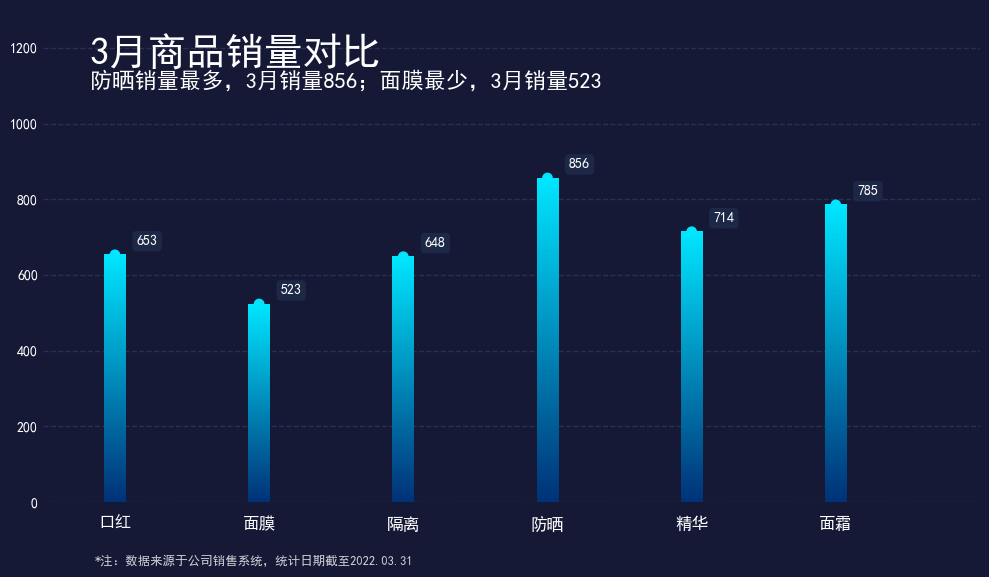

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# 设置中文字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
matplotlib.rcParams['axes.unicode_minus'] = False

# 数据
products = ['口红', '面膜', '隔离', '防晒', '精华', '面霜']
sales = [653, 523, 648, 856, 714, 785]

# 颜色定义
bg_color = '#161936'        # 深蓝背景
text_color = '#FFFFFF'      # 纯白色文字
grid_color = '#2A3050'      # 网格线颜色 (暗灰色虚线)

# 渐变颜色定义 (RGB 0-1) - 底部深蓝，顶部亮青
color_top = np.array([0, 230, 255]) / 255.0   # 顶部亮青 #00E6FF
color_bot = np.array([0, 50, 120]) / 255.0   # 底部深蓝 #003278

# 创建画布
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# 柱子设置 (非常细)
bar_width = 0.15
x_positions = np.arange(len(products)) + 1 

# 1. 绘制渐变柱状图 (细长型)
for i, (x_pos, val) in enumerate(zip(x_positions, sales)):
    rows = 256
    gradient_array = np.zeros((rows, 1, 3))
    for r in range(rows):
        ratio = r / (rows - 1)
        gradient_array[r, 0, :] = color_bot + (color_top - color_bot) * ratio
    
    left = x_pos - bar_width / 2
    right = x_pos + bar_width / 2
    
    # 使用 nearest 插值，保证边缘锐利
    ax.imshow(gradient_array, aspect='auto', extent=[left, right, 0, val],
              origin='lower', zorder=2, interpolation='nearest')

# 2. 绘制顶部的圆点 (Marker)
# 颜色使用顶部亮青色
ax.scatter(x_positions, sales, color=color_top, s=60, zorder=3, edgecolors='none')

# 3. 添加带背景框的数值标签
for i, (x_pos, val) in enumerate(zip(x_positions, sales)):
    # 标签位置在圆点右上方
    ax.text(
        x_pos + 0.15, val + 20,  # 稍微偏右
        str(val),
        ha='left', va='bottom',
        color=text_color,
        fontsize=10,
        zorder=4,
        # 背景框样式：深蓝底色，圆角
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#1E2A4A', edgecolor='none', alpha=0.9)
    )

# 4. 设置标题
ax.text(0.05, 0.95, '3月商品销量对比',
        transform=ax.transAxes,
        fontsize=28, fontweight='bold', color=text_color,
        va='top', ha='left')

ax.text(0.05, 0.88, '防晒销量最多，3月销量856；面膜最少，3月销量523',
        transform=ax.transAxes,
        fontsize=16, fontweight='normal', color=text_color,
        va='top', ha='left')

# 5. 设置坐标轴
ax.set_xticks(x_positions)
ax.set_xticklabels(products, color=text_color, fontsize=12)
ax.tick_params(axis='x', length=0, pad=10)

ax.set_ylim(0, 1300)
ax.set_yticks([0, 200, 400, 600, 800, 1000, 1200])
ax.set_yticklabels(['0', '200', '400', '600', '800', '1000', '1200'], color=text_color, fontsize=10)
ax.tick_params(axis='y', length=0)

# 6. 设置网格线 (水平虚线)
ax.yaxis.grid(True, linestyle='--', color=grid_color, linewidth=1, zorder=1)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# 隐藏边框
for spine in ax.spines.values():
    spine.set_visible(False)

# 设置X轴范围，给右侧标签留空间
ax.set_xlim(0.5, 7.0)

# 7. 添加底部注释
fig.text(
    0.1, 0.05,
    '*注：数据来源于公司销售系统，统计日期截至2022.03.31',
    color=text_color,
    fontsize=9,
    alpha=0.8
)

# 调整布局
plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.show()

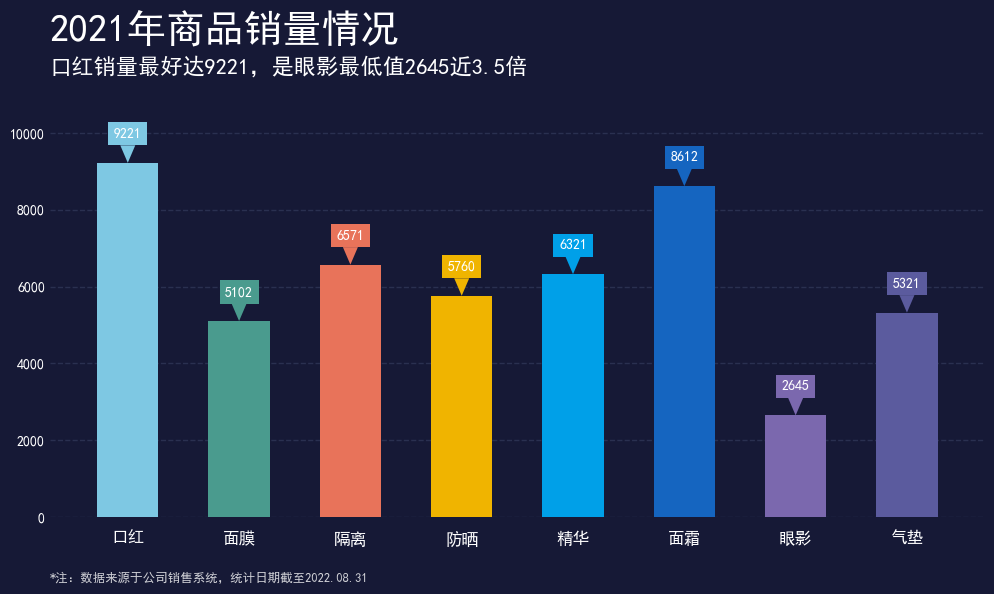

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# 设置中文字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
matplotlib.rcParams['axes.unicode_minus'] = False

# 数据
products = ['口红', '面膜', '隔离', '防晒', '精华', '面霜', '眼影', '气垫']
sales = [9221, 5102, 6571, 5760, 6321, 8612, 2645, 5321]

# 每根柱子的颜色
bar_colors = [
    '#7EC8E3',  # 口红 - 浅天蓝
    '#4A9B8E',  # 面膜 - 青绿色
    '#E8735A',  # 隔离 - 珊瑚橙
    '#F0B400',  # 防晒 - 金黄色
    '#00A0E8',  # 精华 - 亮蓝色
    '#1565C0',  # 面霜 - 深蓝色
    '#7B68AE',  # 眼影 - 蓝紫色
    '#5B5B9E',  # 气垫 - 深靛蓝
]

# 颜色定义
bg_color = '#161936'
text_color = '#FFFFFF'
grid_color = '#2A3050'

# 1. 创建画布 (手动控制布局)
fig = plt.figure(figsize=(11, 6.5))
fig.patch.set_facecolor(bg_color)

# 2. 放置标题 (在 Figure 坐标系中，y=0.92 附近，绝对在图表上方)
fig.text(0.1, 0.93, '2021年商品销量情况', 
         color=text_color, fontsize=28, fontweight='bold', va='top')
fig.text(0.1, 0.86, '口红销量最好达9221，是眼影最低值2645近3.5倍', 
         color=text_color, fontsize=16, va='top')

# 3. 创建图表区域 (在标题下方)
ax = fig.add_axes([0.1, 0.15, 0.85, 0.65]) 
ax.set_facecolor(bg_color)

# 柱子设置
bar_width = 0.55
x_positions = np.arange(len(products)) + 1 

# 4. 绘制彩色柱状图
for i, (x_pos, val, color) in enumerate(zip(x_positions, sales, bar_colors)):
    ax.bar(x_pos, val, width=bar_width, color=color, zorder=2, edgecolor='none')

# 5. 添加带小三角尾巴的标签框 (标签位置再往上抬，避免拥挤)
for i, (x_pos, val, color) in enumerate(zip(x_positions, sales, bar_colors)):
    ax.annotate(
        str(val),
        xy=(x_pos, val),              # 箭头尖端指向柱子顶部
        xytext=(x_pos, val + 600),    # 【修改】标签框位置从 +500 改为 +600，更靠上
        ha='center', va='bottom',
        color='white',
        fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle='square,pad=0.4', facecolor=color, edgecolor='none'),
        arrowprops=dict(
            arrowstyle='wedge,tail_width=0.6',
            facecolor=color,
            edgecolor='none',
            mutation_scale=18,
            shrinkA=0,
            shrinkB=0
        ),
        zorder=4
    )

# 6. 设置坐标轴
ax.set_xticks(x_positions)
ax.set_xticklabels(products, color=text_color, fontsize=12)
ax.tick_params(axis='x', length=0, pad=10)

ax.set_ylim(0, 11000)
ax.set_yticks([0, 2000, 4000, 6000, 8000, 10000])
ax.set_yticklabels(['0', '2000', '4000', '6000', '8000', '10000'], color=text_color, fontsize=10)
ax.tick_params(axis='y', length=0)

# 7. 设置网格线
ax.yaxis.grid(True, linestyle='--', color=grid_color, linewidth=1, zorder=1)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# 隐藏边框
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlim(0.3, 8.7)

# 8. 添加底部注释
fig.text(
    0.1, 0.05,
    '*注：数据来源于公司销售系统，统计日期截至2022.08.31',
    color=text_color,
    fontsize=9,
    alpha=0.8
)

plt.show()

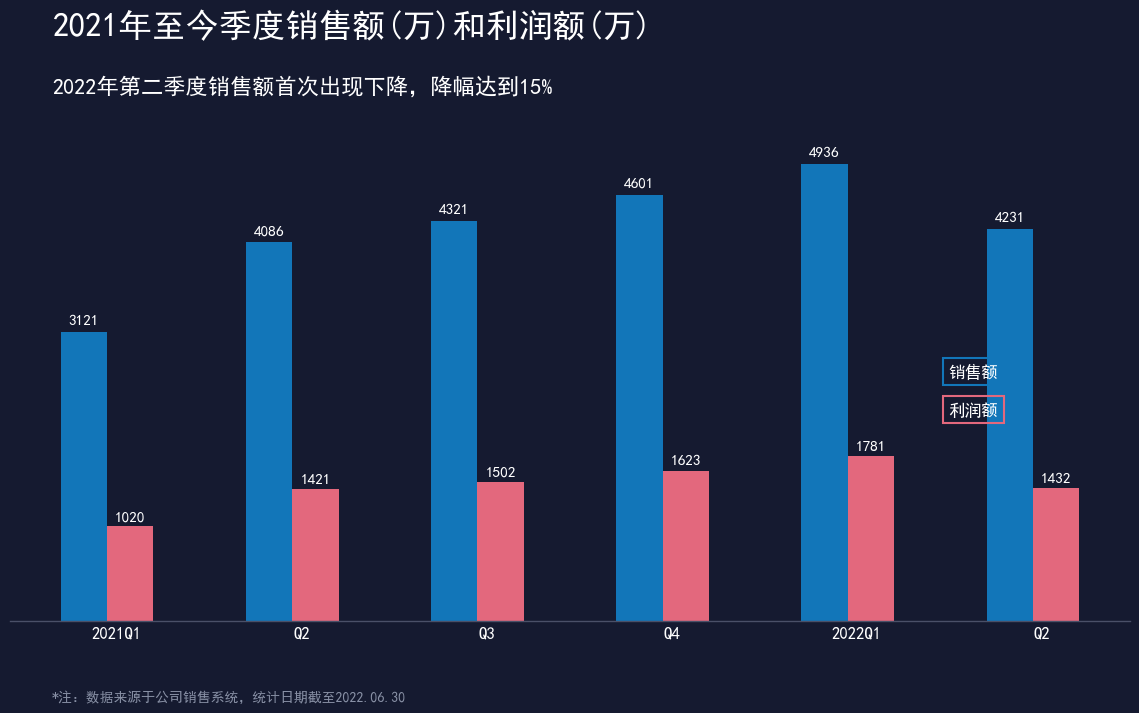

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 设置中文字体 (根据你的系统选择，Windows通常用SimHei或Microsoft YaHei，Mac用Arial Unicode MS)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 2. 数据准备
labels = ['2021Q1', 'Q2', 'Q3', 'Q4', '2022Q1', 'Q2']
sales = [3121, 4086, 4321, 4601, 4936, 4231]
profit = [1020, 1421, 1502, 1623, 1781, 1432]

x = np.arange(len(labels))
width = 0.25  # 柱子宽度

# 3. 创建画布
fig, ax = plt.subplots(figsize=(14, 8))
bg_color = '#151a30'  # 深蓝色背景
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# 4. 绘制柱状图
# 稍微调整 x 坐标让分组更紧凑
rects1 = ax.bar(x - width/2 - 0.05, sales, width, label='Sales', color='#1276b9', zorder=2)
rects2 = ax.bar(x + width/2 - 0.05, profit, width, label='Profit', color='#e3687d', zorder=2)

# 5. 添加柱子顶部的数值标签
def add_labels(rects, offset_y=50):
    for rect in rects:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., height + offset_y,
                f'{int(height)}',
                ha='center', va='bottom', color='white', fontsize=11, fontweight='bold')

add_labels(rects1, offset_y=60)
add_labels(rects2, offset_y=40) # 利润额柱子较矮，标签稍微低一点以免太突兀，或者保持一致

# 6. 设置 X 轴
ax.set_xticks(x)
ax.set_xticklabels(labels, color='white', fontsize=12)
ax.tick_params(axis='x', length=0) # 去掉X轴刻度线

# 7. 隐藏 Y 轴和边框
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# 设置底部边框为灰色细线
ax.spines['bottom'].set_color('#4a5068')
ax.spines['bottom'].set_linewidth(1)

# 8. 添加标题和副标题 (使用 fig.text 精确定位)
fig.text(0.13, 0.88, '2021年至今季度销售额(万)和利润额(万)', 
         color='white', fontsize=24, fontweight='bold', family='sans-serif')
fig.text(0.13, 0.81, '2022年第二季度销售额首次出现下降，降幅达到15%', 
         color='white', fontsize=16, family='sans-serif')

# 9. 添加自定义图例 (模拟原图的带框文字)
# 销售额图例
ax.text(0.86, 0.52, '销售额', transform=ax.transAxes,
        color='white', fontsize=12,
        bbox=dict(facecolor='none', edgecolor='#1276b9', linewidth=1.5),
        ha='center', va='center')
# 利润额图例
ax.text(0.86, 0.44, '利润额', transform=ax.transAxes,
        color='white', fontsize=12,
        bbox=dict(facecolor='none', edgecolor='#e3687d', linewidth=1.5),
        ha='center', va='center')

# 10. 添加底部注释
fig.text(0.13, 0.05, '*注：数据来源于公司销售系统，统计日期截至2022.06.30', 
         color='#8890a5', fontsize=10)

# 11. 调整布局
plt.subplots_adjust(left=0.1, right=0.9, top=0.75, bottom=0.15)

# 显示图表
plt.show()

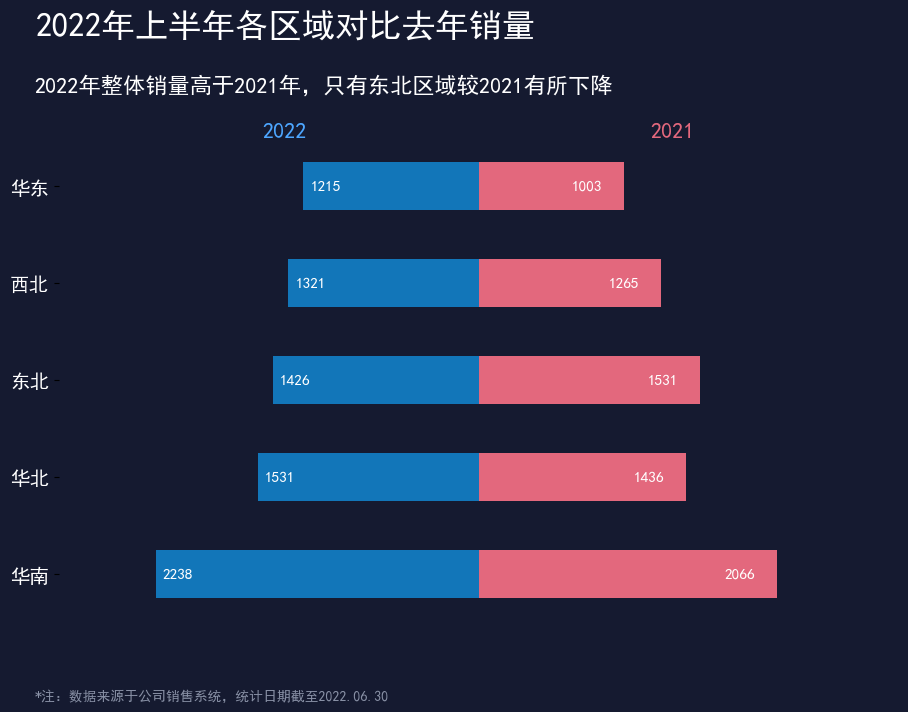

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 2. 数据准备 (按图表从上到下的顺序，即2022年销量降序)
regions = ['华南', '华北', '东北', '西北', '华东']
sales_2022 = [2238, 1531, 1426, 1321, 1215]
sales_2021 = [2066, 1436, 1531, 1265, 1003]

y = np.arange(len(regions))

# 3. 创建画布
fig, ax = plt.subplots(figsize=(12, 8))
bg_color = '#151a30'
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# 4. 绘制条形图
# 左侧 (2022年): 使用负值使其向左延伸
# 颜色: 蓝色 #1276b9
bar_left = ax.barh(y, [-x for x in sales_2022], height=0.5, color='#1276b9', zorder=2)

# 右侧 (2021年): 使用正值使其向右延伸
# 颜色: 粉色 #e3687d
bar_right = ax.barh(y, sales_2021, height=0.5, color='#e3687d', zorder=2)

# 5. 添加条形图内部的数值标签
# 左侧标签 (2022)
for i, val in enumerate(sales_2022):
    # x位置：负值 + 一点偏移量，使其在条形图内部左侧
    # 原图数字在条形图左侧内部
    ax.text(-val + 50, i, str(val), ha='left', va='center', color='white', fontsize=11)

# 右侧标签 (2021)
for i, val in enumerate(sales_2021):
    # x位置：正值 - 一点偏移量，使其在条形图内部右侧
    ax.text(val - 150, i, str(val), ha='right', va='center', color='white', fontsize=11) # 偏移量大一点防止溢出

# 6. 设置 Y 轴 (中间的区域名)
ax.set_yticks(y)
ax.set_yticklabels(regions, color='white', fontsize=14, fontweight='bold')
# 调整Y轴标签位置到中间 (x=0附近)
ax.yaxis.set_label_coords(-0.05, 0.5) # 微调

# 7. 隐藏 X 轴和边框
ax.set_xticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# 8. 添加顶部的 "2022" 和 "2021" 标题
# 需要根据数据最大值动态计算位置，或者手动指定
max_val = max(max(sales_2022), max(sales_2021))
ax.text(-max_val * 0.6, len(regions) - 0.5, '2022', color='#4da6ff', fontsize=16, ha='center', fontweight='bold') # 淡蓝色
ax.text(max_val * 0.6, len(regions) - 0.5, '2021', color='#e3687d', fontsize=16, ha='center', fontweight='bold') # 淡粉色/红色

# 9. 添加主标题和副标题 (使用 fig.text)
fig.text(0.13, 0.88, '2022年上半年各区域对比去年销量', 
         color='white', fontsize=24, fontweight='bold')
fig.text(0.13, 0.81, '2022年整体销量高于2021年，只有东北区域较2021有所下降', 
         color='white', fontsize=16)

# 10. 添加底部注释
fig.text(0.13, 0.05, '*注：数据来源于公司销售系统，统计日期截至2022.06.30', 
         color='#8890a5', fontsize=10)

# 11. 调整 X 轴范围，留出中间空隙放文字
# 左边留够空间放2022的条，右边留够空间放2021的条，中间留空
ax.set_xlim(-max_val * 1.3, max_val * 1.3)

# 12. 调整布局
plt.subplots_adjust(left=0.15, right=0.85, top=0.75, bottom=0.15)

plt.show()

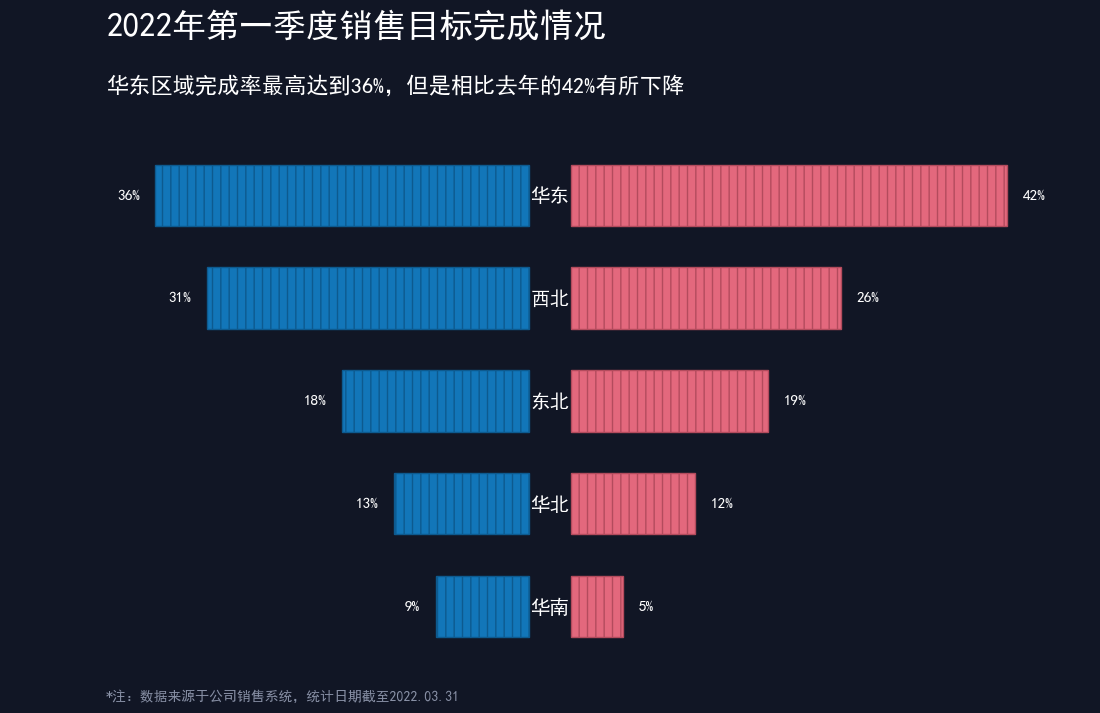

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['hatch.linewidth'] = 1.0 

# 2. 数据准备 (从小到大：华南 -> 华东，形成正金字塔)
regions = ['华南', '华北', '东北', '西北', '华东']
sales_2022 = [9, 13, 18, 31, 36]   # 左侧蓝色
sales_2021 = [5, 12, 19, 26, 42]   # 右侧粉色

y = np.arange(len(regions))

# 3. 创建画布
fig, ax = plt.subplots(figsize=(12, 8)) # 高度稍微增加一点给标题留空间
bg_color = '#111625' 
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# 4. 绘制条形图 (核心对齐逻辑)
gap = 2  # 中间留空距离
height = 0.6

# 左侧 (2022) - 蓝色
bar_left = ax.barh(y, [-x for x in sales_2022], height=height, 
                   left=[-gap] * len(sales_2022),  
                   color='#1276b9', edgecolor='#0d5a8f', hatch='||', zorder=2)

# 右侧 (2021) - 粉色
bar_right = ax.barh(y, sales_2021, height=height, 
                    left=[gap] * len(sales_2021),   
                    color='#e3687d', edgecolor='#b34b5d', hatch='||', zorder=2)

# 5. 添加标签
# 左侧标签 (在条形左侧外部)
for i, val in enumerate(sales_2022):
    x_pos = -gap - val - 1.5 
    ax.text(x_pos, i, f'{val}%', ha='right', va='center', color='white', fontsize=11, fontweight='bold')

# 右侧标签 (在条形右侧外部)
for i, val in enumerate(sales_2021):
    x_pos = gap + val + 1.5
    ax.text(x_pos, i, f'{val}%', ha='left', va='center', color='white', fontsize=11)

# 6. 中间的区域名称 (完美对齐在 x=0)
ax.set_yticks([]) 
for i, region in enumerate(regions):
    ax.text(0, i, region, ha='center', va='center', color='white', fontsize=14, fontweight='bold')

# 7. 隐藏坐标轴和边框
ax.set_xticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# 8. 设置X轴范围
max_val = max(max(sales_2022), max(sales_2021))
ax.set_xlim(-gap - max_val - 8, gap + max_val + 8)

# 9. 添加标题和副标题 (补回来了！)
fig.text(0.13, 0.88, '2022年第一季度销售目标完成情况', 
         color='white', fontsize=24, fontweight='bold')
fig.text(0.13, 0.81, '华东区域完成率最高达到36%，但是相比去年的42%有所下降', 
         color='white', fontsize=16)

# 10. 添加底部注释
fig.text(0.13, 0.05, '*注：数据来源于公司销售系统，统计日期截至2022.03.31', 
         color='#8890a5', fontsize=10)

# 11. 调整布局 (top调大，给标题留出空间)
plt.subplots_adjust(left=0.05, right=0.95, top=0.75, bottom=0.1)

plt.show()

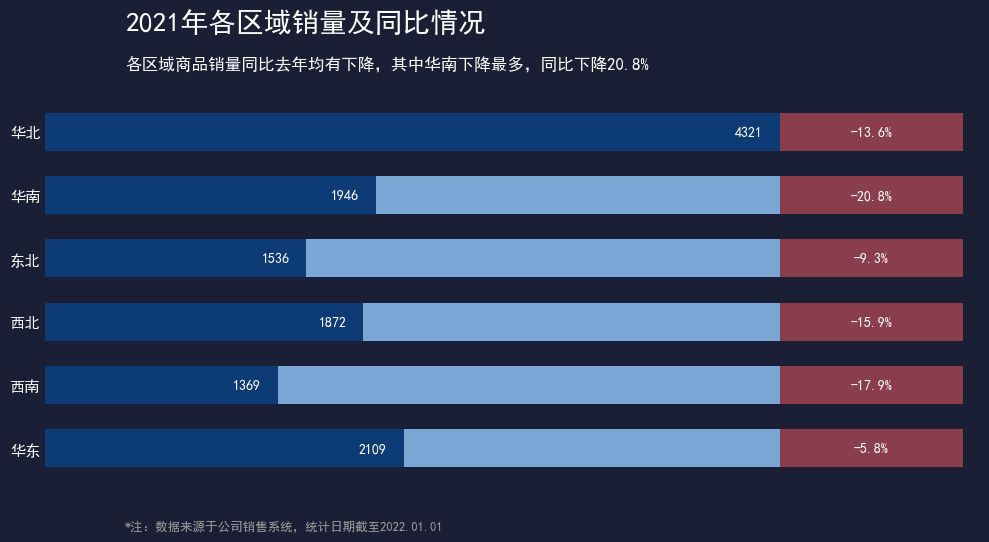

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体（根据你的系统环境调整，Windows常用SimHei，Mac常用Arial Unicode MS或PingFang SC）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 1. 准备数据
# 注意：图表中的顺序是从上到下：华东、西南、西北、东北、华南、华北（即原表的倒序）
regions = ['华东', '西南', '西北', '东北', '华南', '华北']
sales = [2109, 1369, 1872, 1536, 1946, 4321]       # 销量 (深蓝色条)
placeholder1 = [2212, 2952, 2449, 2785, 2375, 0]   # 占位1 (浅蓝色条，用于补齐长度)
placeholder2 = [1080, 1080, 1080, 1080, 1080, 1080] # 占位2 (红色条，固定宽度)
yoy = ['-5.8%', '-17.9%', '-15.9%', '-9.3%', '-20.8%', '-13.6%'] # 同比数据

# 2. 创建画布和背景色
fig, ax = plt.subplots(figsize=(10, 6))
bg_color = '#1a1f35'  # 深蓝色背景
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# Y轴位置
y_pos = np.arange(len(regions))

# 3. 绘制堆积条形图
# 顺序：销量(深蓝) -> 占位1(浅蓝) -> 占位2(红)
# 这样深蓝色条都在最左侧，符合原图视觉效果
bar_height = 0.6

# 第一层：销量 (深蓝色)
b1 = ax.barh(y_pos, sales, height=bar_height, color='#0d3b75', label='销量')

# 第二层：占位1 (浅蓝色)，left参数使其接在销量后面
b2 = ax.barh(y_pos, placeholder1, height=bar_height, left=sales, color='#7ba7d6', label='占位')

# 第三层：占位2 (暗红色)，left参数使其接在占位1后面
left_pos_3 = [s + p for s, p in zip(sales, placeholder1)]
b3 = ax.barh(y_pos, placeholder2, height=bar_height, left=left_pos_3, color='#8a3d4b', label='同比')

# 4. 添加文字标签
# 在深蓝色条中添加销量数值 (靠右对齐)
for i, (v, p1) in enumerate(zip(sales, placeholder1)):
    # 如果销量很大（如华北），文字放在条形内部靠右；如果较小，也放在内部
    # 原图中文字似乎都在深蓝色块的右侧边缘附近
    ax.text(v - 100, i, str(v), va='center', ha='right', color='white', fontsize=10, fontweight='bold')

# 在红色条中添加同比百分比 (居中)
for i, (v, text) in enumerate(zip(placeholder2, yoy)):
    # 计算红色条的中心x坐标
    center_x = left_pos_3[i] + v / 2
    ax.text(center_x, i, text, va='center', ha='center', color='white', fontsize=10)

# 5. 设置Y轴标签
ax.set_yticks(y_pos)
ax.set_yticklabels(regions, color='white', fontsize=11)
ax.tick_params(axis='y', length=0) # 隐藏刻度线

# 6. 添加标题和副标题
# 使用 fig.text 以便在坐标系外定位
fig.text(0.13, 0.88, '2021年各区域销量及同比情况', color='white', fontsize=20, fontweight='bold')
fig.text(0.13, 0.82, '各区域商品销量同比去年均有下降，其中华南下降最多，同比下降20.8%', color='white', fontsize=12)

# 7. 添加底部注脚
fig.text(0.13, 0.05, '*注：数据来源于公司销售系统，统计日期截至2022.01.01', color='#a0a0a0', fontsize=9)

# 8. 清理坐标轴
ax.set_xlim(0, 5500) # 设置X轴范围，确保所有条形显示完整 (4321+1080=5401)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.xaxis.set_ticks([]) # 隐藏X轴刻度

plt.tight_layout(rect=[0, 0.1, 1, 0.8]) # 调整布局留出标题和注脚空间
plt.show()

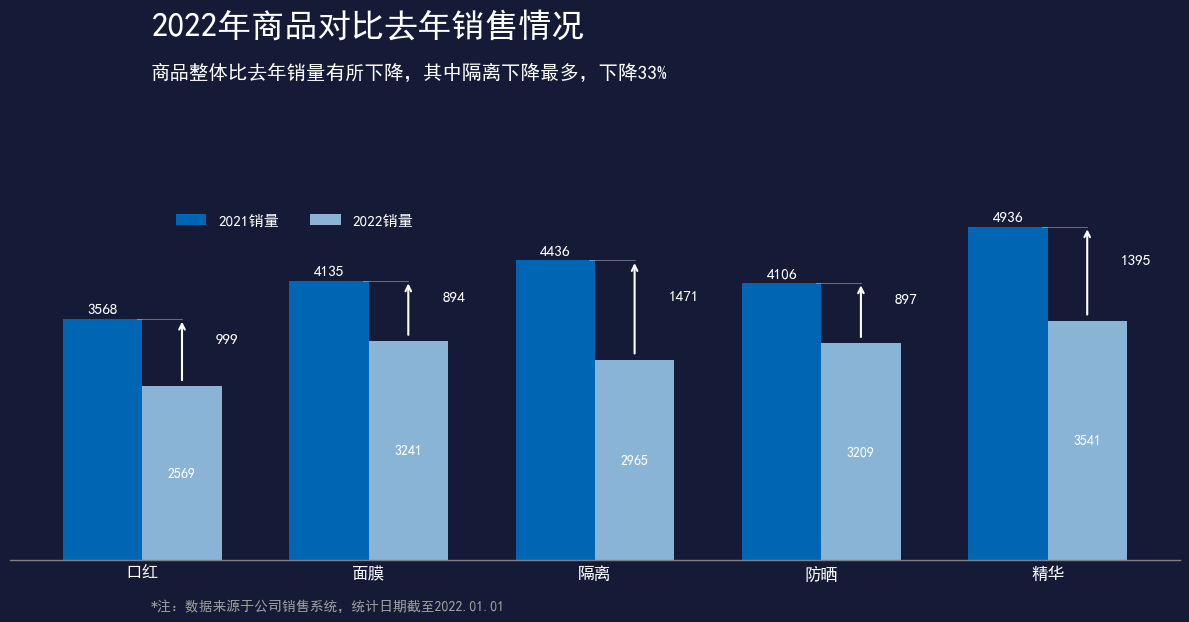

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 1. 数据准备
categories = ['口红', '面膜', '隔离', '防晒', '精华']
sales_2021 = [3568, 4135, 4436, 4106, 4936]
sales_2022 = [2569, 3241, 2965, 3209, 3541]
diff = [s1 - s2 for s1, s2 in zip(sales_2021, sales_2022)]

x = np.arange(len(categories))
width = 0.35

# 2. 创建画布和背景
fig, ax = plt.subplots(figsize=(12, 7))
bg_color = '#151b36'
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# 3. 绘制柱状图
rects1 = ax.bar(x - width/2, sales_2021, width, label='2021销量', color='#0066b3', zorder=2)
rects2 = ax.bar(x + width/2, sales_2022, width, label='2022销量', color='#8ab4d6', zorder=2)

# 4. 添加数值标注和箭头
for i in range(len(categories)):
    # 2021数值 (在柱子上方)
    ax.text(x[i] - width/2, sales_2021[i] + 50, str(sales_2021[i]), 
            ha='center', va='bottom', color='white', fontsize=11, fontweight='bold')
    
    # 2022数值 (在柱子内部)
    ax.text(x[i] + width/2, sales_2022[i] * 0.5, str(sales_2022[i]), 
            ha='center', va='center', color='white', fontsize=10)

    # 辅助线
    ax.plot([x[i] - width/2 + 0.15, x[i] + width/2], [sales_2021[i], sales_2021[i]], 
            color='white', linewidth=0.5, alpha=0.5)

    # 箭头
    ax.annotate('', 
                xy=(x[i] + width/2, sales_2021[i]),  
                xytext=(x[i] + width/2, sales_2022[i] + 50), 
                arrowprops=dict(arrowstyle='->', color='white', lw=1.5))

    # 差值标注
    ax.text(x[i] + width/2 + 0.15, (sales_2021[i] + sales_2022[i]) / 2 + 200, str(diff[i]), 
            ha='left', va='center', color='white', fontsize=11)

# 5. 设置X轴
ax.set_xticks(x)
ax.set_xticklabels(categories, color='white', fontsize=12)
ax.tick_params(axis='x', length=0)

# --- 修改点 1：拉高 Y 轴上限，给顶部留空间 ---
ax.set_ylim(0, 6500)  # 原来是 6000，改为 6500
ax.yaxis.set_ticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('gray')
ax.spines['bottom'].set_linewidth(1)

# 6. 添加标题和副标题
fig.text(0.13, 0.90, '2022年商品对比去年销售情况', color='white', fontsize=24, fontweight='bold')
fig.text(0.13, 0.84, '商品整体比去年销量有所下降，其中隔离下降最多，下降33%', color='white', fontsize=14)

# --- 修改点 2：图例位置往上移 ---
# bbox_to_anchor 的第二个参数从 0.72 改为 0.82 (基于 axes 坐标系，0.82 * 6500 ≈ 5330，高于最高柱子 4936)
legend = ax.legend(loc='upper left', bbox_to_anchor=(0.13, 0.82), 
                   ncol=2, frameon=False, fontsize=11)
for text in legend.get_texts():
    text.set_color('white')

# 7. 添加注脚
fig.text(0.13, 0.08, '*注：数据来源于公司销售系统，统计日期截至2022.01.01', color='#a0a0a0', fontsize=10)

# 调整布局，rect 的 top 设为 0.80，给标题留出空间
plt.tight_layout(rect=[0, 0.1, 1, 0.80]) 
plt.show()

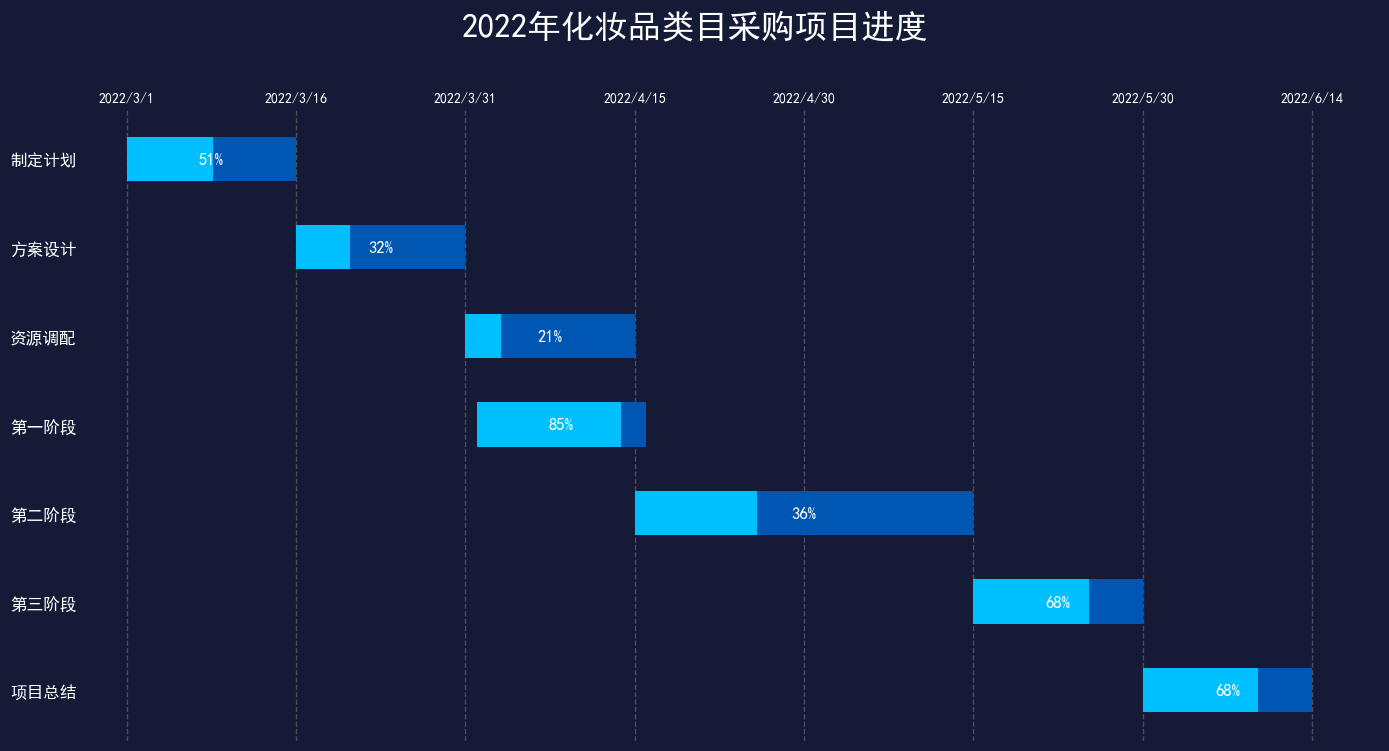

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 1. 数据准备
# 根据原图视觉位置估算的起始日期和持续时间
tasks = ['制定计划', '方案设计', '资源调配', '第一阶段', '第二阶段', '第三阶段', '项目总结']
starts = [
    datetime(2022, 3, 1),   # 对齐 3/1
    datetime(2022, 3, 16),  # 对齐 3/16
    datetime(2022, 3, 31),  # 对齐 3/31 (略微偏右)
    datetime(2022, 4, 1),   # 紧接资源调配之后
    datetime(2022, 4, 15),  # 对齐 4/15
    datetime(2022, 5, 15),  # 对齐 5/15
    datetime(2022, 5, 30)   # 对齐 5/30
]
durations = [15, 15, 15, 15, 30, 15, 15]  # 持续天数 (估算)
progress = [51, 32, 21, 85, 36, 68, 68]   # 进度百分比

# 顶部日期刻度
date_labels = ['2022/3/1', '2022/3/16', '2022/3/31', '2022/4/15', '2022/4/30', '2022/5/15', '2022/5/30', '2022/6/14']
date_ticks = [
    datetime(2022, 3, 1), datetime(2022, 3, 16), datetime(2022, 3, 31),
    datetime(2022, 4, 15), datetime(2022, 4, 30), datetime(2022, 5, 15),
    datetime(2022, 5, 30), datetime(2022, 6, 14)
]

# 2. 创建画布
fig, ax = plt.subplots(figsize=(14, 8))
bg_color = '#151b36'  # 深蓝色背景
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

y_pos = np.arange(len(tasks))

# 颜色定义 (取自原图)
color_progress = '#00bfff'  # 浅蓝色 (已完成部分)
color_total = '#0056b3'     # 深蓝色 (总任务/剩余部分)

# 3. 绘制条形图
for i in range(len(tasks)):
    start_num = mdates.date2num(starts[i])
    dur_num = durations[i]
    
    # 先画深蓝色长条 (代表总时长/背景)
    ax.barh(i, dur_num, height=0.5, left=start_num, color=color_total, zorder=2)
    
    # 再画浅蓝色短条 (代表进度，覆盖在左边)
    prog_dur = dur_num * (progress[i] / 100)
    ax.barh(i, prog_dur, height=0.5, left=start_num, color=color_progress, zorder=3)
    
    # 添加百分比文字 (白色，居中)
    center_x = start_num + dur_num / 2
    ax.text(center_x, i, f'{progress[i]}%', ha='center', va='center', 
            color='white', fontsize=12, fontweight='bold', zorder=4)

# 4. 绘制垂直虚线网格
for dt in date_ticks:
    ax.axvline(x=mdates.date2num(dt), color='gray', linestyle='--', linewidth=1, alpha=0.5, zorder=1)

# 5. 设置 X 轴 (日期在顶部)
ax.set_xlim(mdates.date2num(datetime(2022, 2, 25)), mdates.date2num(datetime(2022, 6, 20)))
ax.set_xticks([mdates.date2num(dt) for dt in date_ticks])
ax.set_xticklabels(date_labels, color='white', fontsize=10)
ax.xaxis.tick_top()  # 刻度移到顶部
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', length=0) # 隐藏刻度线

# 6. 设置 Y 轴
ax.set_yticks(y_pos)
ax.set_yticklabels(tasks, color='white', fontsize=12)
ax.tick_params(axis='y', length=0)
ax.invert_yaxis() # 反转Y轴，让"制定计划"在最上面

# 7. 隐藏边框
for spine in ax.spines.values():
    spine.set_visible(False)

# 8. 添加标题
fig.text(0.5, 0.95, '2022年化妆品类目采购项目进度', color='white', 
         fontsize=24, fontweight='bold', ha='center')

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.show()